# Customer Churn Prediction

This project uses the Telco Customer Churn dataset from Kaggle. The goal is to predict whether a customer will leave the company or not.

The task is a classification problem. The methods used are Random Forest, Boosting, and Support Vector Machine (SVM).

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


## Loading the Dataset

The dataset was downloaded as a ZIP file from Kaggle. In this step, the file is extracted and loaded into a pandas DataFrame.

In [ ]:
import zipfile
import os
import pandas as pd

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("telco_churn_data")

os.listdir("telco_churn_data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [ ]:
df = pd.read_csv("telco_churn_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Dataset Inspection

In this step, we check the size of the dataset, the number of attributes, and the data types of the columns.

In [ ]:
print("Dataset shape:", df.shape)
print("Number of records:", df.shape[0])
print("Number of attributes:", df.shape[1])

df.info()

Dataset shape: (7043, 21)
Number of records: 7043
Number of attributes: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract      

## Attribute Types

The dataset contains both categorical and numerical attributes. Most columns are categorical, such as gender, contract type, payment method, and internet service. The numerical attributes include tenure, monthly charges, and total charges.

The column `TotalCharges` is currently stored as text, so it will be cleaned and converted to a numerical variable later.

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

print("\nNumber of categorical columns:", len(categorical_columns))
print("Number of numerical columns:", len(numerical_columns))

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Number of categorical columns: 18
Number of numerical columns: 3


## Missing Values

In this step, we check if the dataset contains missing values. Missing values must be identified before training the models because they can affect the results.

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Values,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


## Checking the TotalCharges Column

The column `TotalCharges` should be numerical, but it was loaded as text. We check if it contains empty spaces or invalid values.

In [ ]:
df['TotalCharges'].value_counts().head()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8


In [ ]:
print("Number of empty spaces in TotalCharges:")
print((df['TotalCharges'] == ' ').sum())

Number of empty spaces in TotalCharges:
11


## Cleaning TotalCharges

The `TotalCharges` column contains 11 empty space values. These values are not detected as missing values because they are stored as text. We replace them with missing values, convert the column to numeric, and remove the rows with missing `TotalCharges`.

In [ ]:
import numpy as np

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print("Missing values in TotalCharges after conversion:")
print(df['TotalCharges'].isnull().sum())

Missing values in TotalCharges after conversion:
11


In [ ]:
df = df.dropna(subset=['TotalCharges'])

print("Dataset shape after cleaning:", df.shape)
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Dataset shape after cleaning: (7032, 21)
Missing values after cleaning:
0


## Dataset After Cleaning

After cleaning, the dataset no longer contains invalid values in `TotalCharges`. The column is now numerical and can be used for statistical analysis and model training.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

## Target Variable Distribution

The target variable is `Churn`. It shows whether a customer left the company or stayed with the company. In this step, we check the number and percentage of customers in each class.

In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(churn_percentages)

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


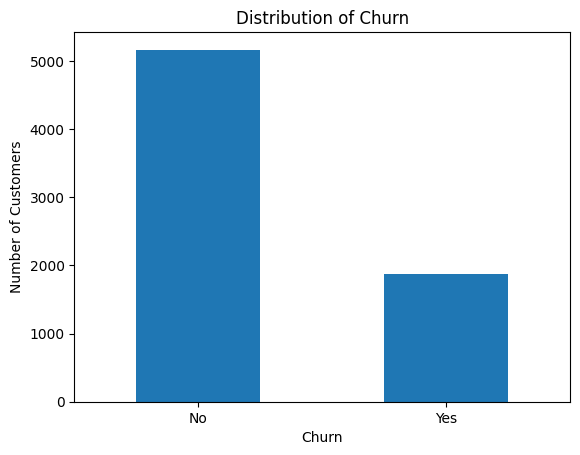

In [ ]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## Statistical Analysis of Numerical Attributes

In this step, we analyze the numerical attributes of the dataset. We calculate the mean, median, mode, and standard deviation for each numerical column.

In [ ]:
numerical_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

numerical_stats = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std(),
    'Minimum': df[numerical_columns].min(),
    'Maximum': df[numerical_columns].max()
})

numerical_stats

,Mean,Median,Mode,Standard Deviation,Minimum,Maximum
SeniorCitizen,0.162400,0.000,0.00,0.368844,0.00,1.00
tenure,32.421786,29.000,1.00,24.545260,1.00,72.00
MonthlyCharges,64.798208,70.350,20.05,30.085974,18.25,118.75
TotalCharges,2283.300441,1397.475,20.20,2266.771362,18.80,8684.80


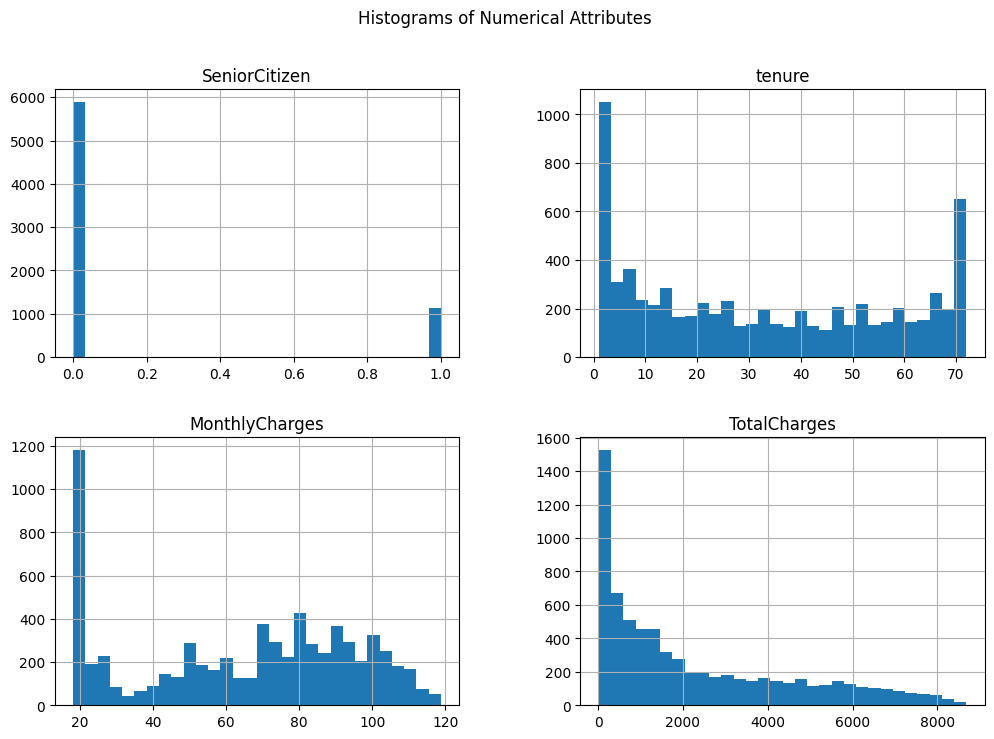

In [ ]:
df[numerical_columns].hist(figsize=(12, 8), bins=30)

plt.suptitle("Histograms of Numerical Attributes")
plt.show()

## Statistical Analysis of Categorical Attributes

In this step, we analyze the categorical attributes. For categorical variables, the most useful statistics are the unique values, the mode, and the frequency of each category.

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

categorical_columns.remove('customerID')

categorical_summary = pd.DataFrame({
    'Number of Unique Values': df[categorical_columns].nunique(),
    'Mode': df[categorical_columns].mode().iloc[0]
})

categorical_summary

,Number of Unique Values,Mode
gender,2,Male
Partner,2,No
Dependents,2,No
PhoneService,2,Yes
MultipleLines,3,No
InternetService,3,Fiber optic
OnlineSecurity,3,No
OnlineBackup,3,No
DeviceProtection,3,No
TechSupport,3,No


## Distribution of Important Categorical Attributes

The following plots show the distribution of important categorical attributes that may influence customer churn.

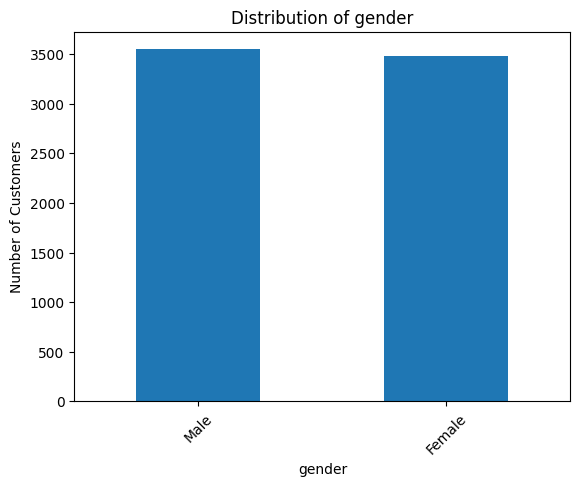

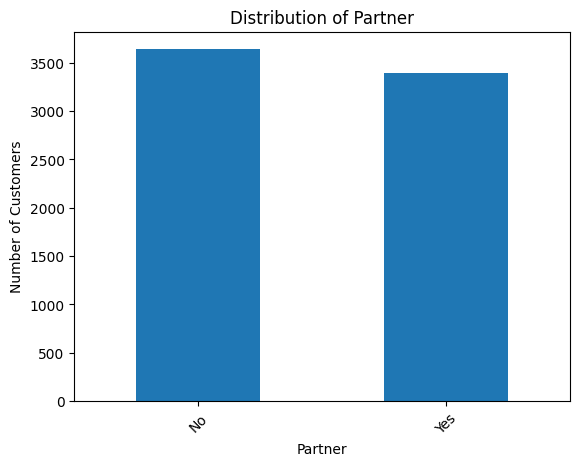

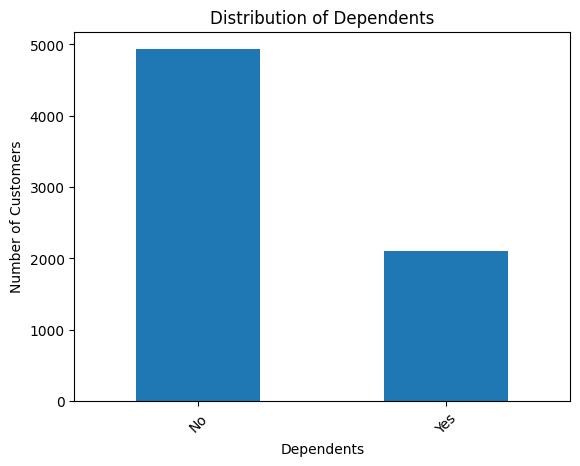

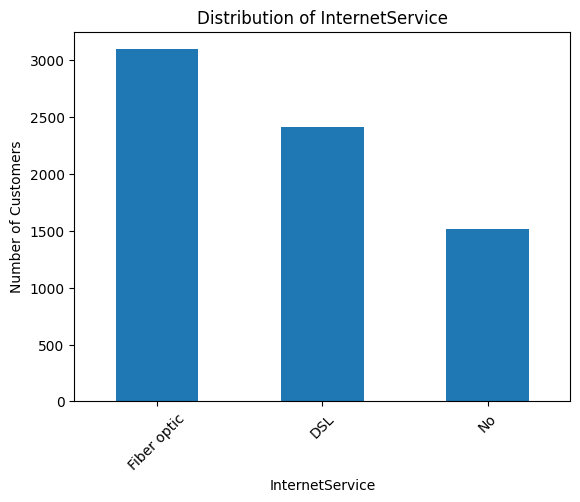

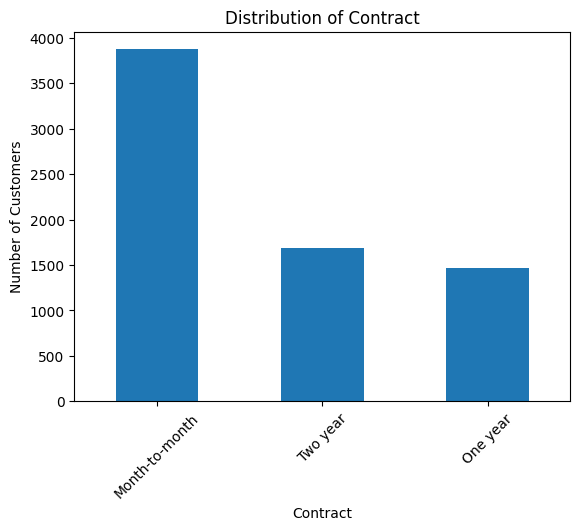

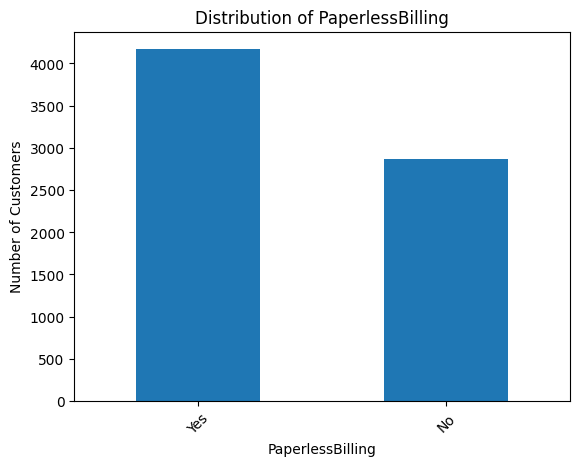

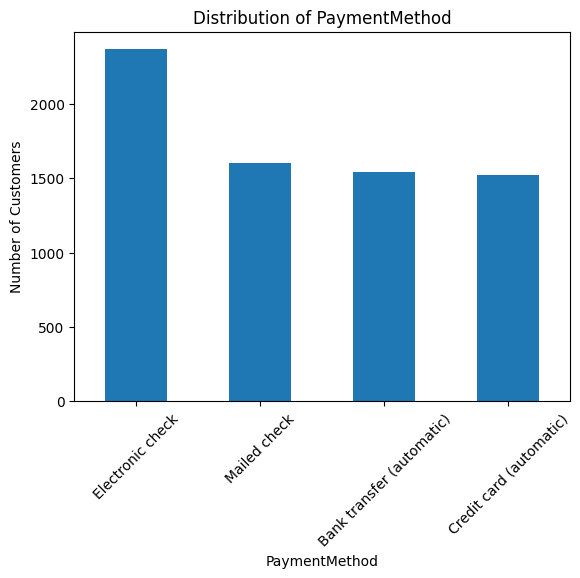

In [ ]:
important_categorical_columns = ['gender', 'Partner', 'Dependents', 'InternetService',
                                 'Contract', 'PaperlessBilling', 'PaymentMethod']

for column in important_categorical_columns:
    df[column].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.show()

## Numerical Attributes Compared with Churn

In this step, we compare numerical attributes with the target variable. This helps us see if customers who churn have different values for tenure, monthly charges, or total charges.

In [ ]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


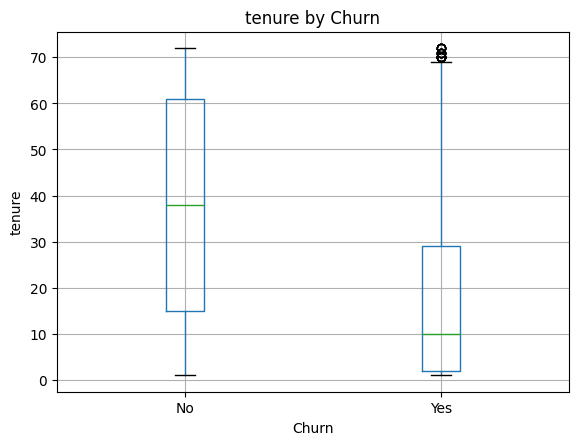

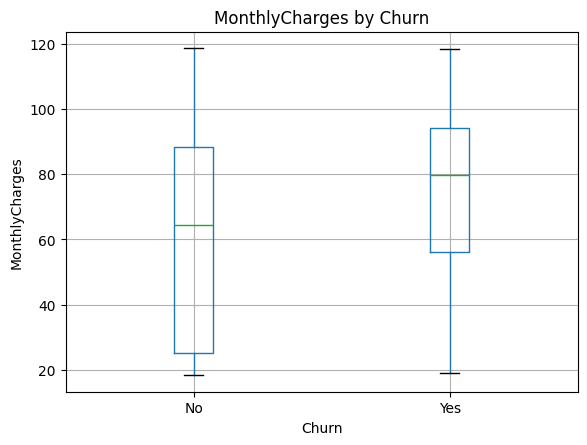

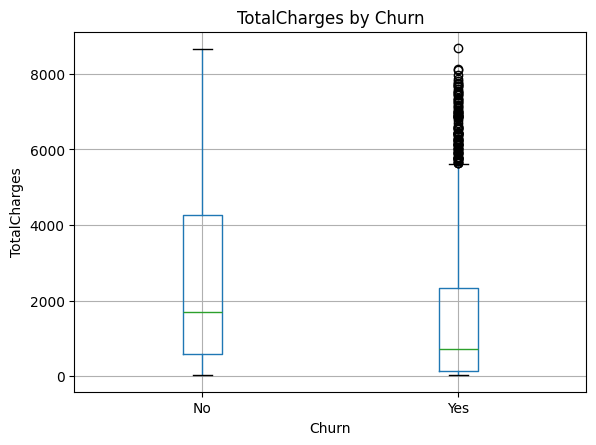

In [ ]:
for column in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    df.boxplot(column=column, by='Churn')
    plt.title(f"{column} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(column)
    plt.show()

## Correlation Between Numerical Attributes

The correlation matrix shows the relationship between numerical attributes. This helps us understand if some variables are strongly related to each other.

In [ ]:
correlation_matrix = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


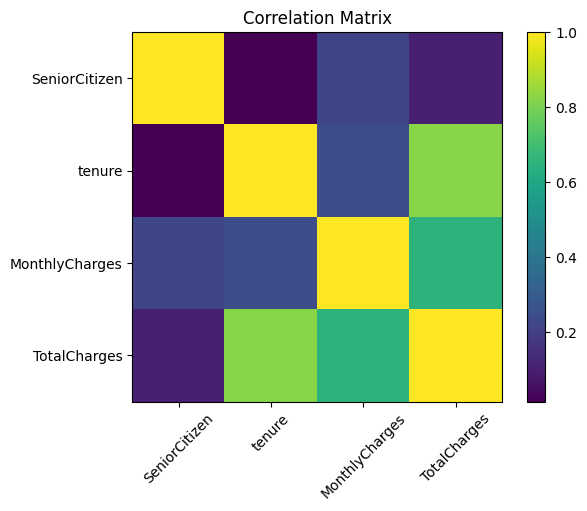

In [ ]:
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

## Data Preprocessing for Machine Learning

Before training the models, the dataset must be prepared. The `customerID` column is removed because it is only an identifier. The target variable `Churn` is converted into numerical values, where `No` becomes 0 and `Yes` becomes 1. Categorical variables are encoded using one-hot encoding.

In [ ]:
data = df.copy()

data = data.drop('customerID', axis=1)

data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

data_encoded = pd.get_dummies(data, drop_first=True)

data_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Features and Target Variable

The dataset is divided into input features and the target variable. The input features are used by the models to predict customer churn.

In [ ]:
X = data_encoded.drop('Churn', axis=1)
y = data_encoded['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 30)
Target shape: (7032,)


## Train-Test Split

The data is divided into training and testing sets. The training set is used to train the models, while the test set is used to evaluate their performance on unseen data. Stratification is used to keep the same churn distribution in both sets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (5625, 30)
Test set shape: (1407, 30)

Training target distribution:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Test target distribution:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


## Feature Scaling

Feature scaling is applied because SVM is sensitive to the scale of the input variables. Tree-based models such as Random Forest and Boosting do not strictly require scaling, but the scaled data will be used for SVM.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Random Forest

The first model used is Random Forest. This method builds many decision trees and combines their predictions. It is useful for classification problems and can also show which features are important for prediction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)
print("ROC-AUC:", rf_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Results
Accuracy: 0.7889125799573561
Precision: 0.6323024054982818
Recall: 0.4919786096256685
F1-score: 0.5533834586466165
ROC-AUC: 0.8176693188936226

Confusion Matrix:
[[926 107]
 [190 184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



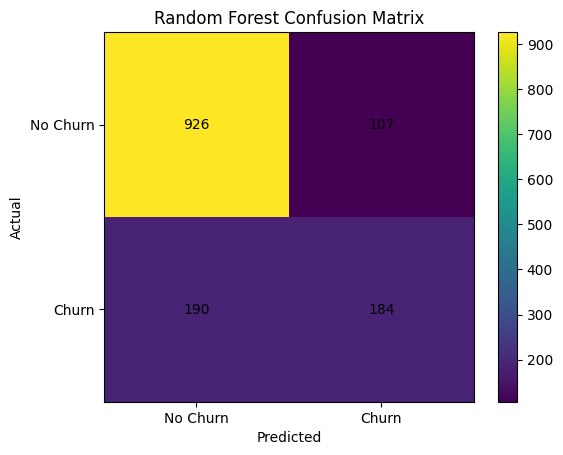

In [ ]:
cm = confusion_matrix(y_test, rf_predictions)

plt.imshow(cm)
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Model 2: Gradient Boosting

The second model used is Gradient Boosting. This method builds several weak models step by step, where each new model tries to correct the errors of the previous ones. It is often effective for classification problems.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)
gb_probabilities = gb_model.predict_proba(X_test)[:, 1]

In [ ]:
gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_precision = precision_score(y_test, gb_predictions)
gb_recall = recall_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions)
gb_roc_auc = roc_auc_score(y_test, gb_probabilities)

print("Gradient Boosting Results")
print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1-score:", gb_f1)
print("ROC-AUC:", gb_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_predictions))

print("\nClassification Report:")
print(classification_report(y_test, gb_predictions))

Gradient Boosting Results
Accuracy: 0.7953091684434968
Precision: 0.6378205128205128
Recall: 0.5320855614973262
F1-score: 0.5801749271137027
ROC-AUC: 0.8406774308773057

Confusion Matrix:
[[920 113]
 [175 199]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



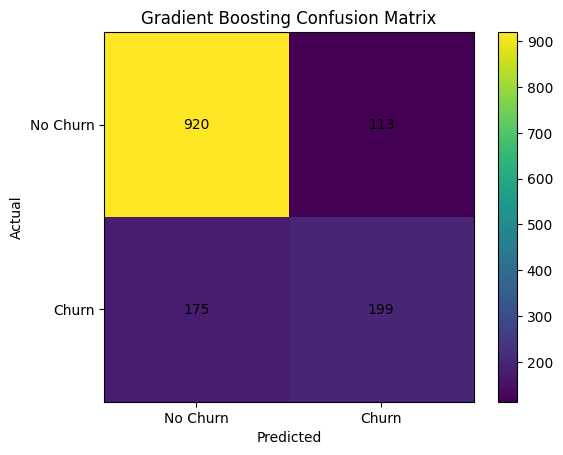

In [ ]:
cm = confusion_matrix(y_test, gb_predictions)

plt.imshow(cm)
plt.title("Gradient Boosting Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Model 3: Support Vector Machine

The third model used is Support Vector Machine. SVM tries to find a decision boundary that separates the two classes. Because SVM is sensitive to feature scale, the scaled training and test sets are used.

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_predictions = svm_model.predict(X_test_scaled)
svm_probabilities = svm_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)
svm_roc_auc = roc_auc_score(y_test, svm_probabilities)

print("SVM Results")
print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)
print("ROC-AUC:", svm_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))

print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))

SVM Results
Accuracy: 0.7270788912579957
Precision: 0.49155405405405406
Recall: 0.7780748663101604
F1-score: 0.6024844720496895
ROC-AUC: 0.8044142236671137

Confusion Matrix:
[[732 301]
 [ 83 291]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



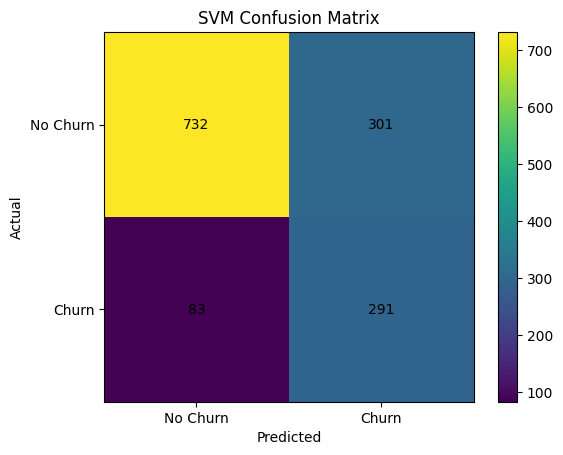

In [ ]:
cm = confusion_matrix(y_test, svm_predictions)

plt.imshow(cm)
plt.title("SVM Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Model Comparison

In this section, the three models are compared using the same evaluation metrics. This helps identify which model performs best for customer churn prediction.

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'SVM'],
    'Accuracy': [rf_accuracy, gb_accuracy, svm_accuracy],
    'Precision': [rf_precision, gb_precision, svm_precision],
    'Recall': [rf_recall, gb_recall, svm_recall],
    'F1-score': [rf_f1, gb_f1, svm_f1],
    'ROC-AUC': [rf_roc_auc, gb_roc_auc, svm_roc_auc]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.788913,0.632302,0.491979,0.553383,0.817669
1,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.840677
2,SVM,0.727079,0.491554,0.778075,0.602484,0.804414


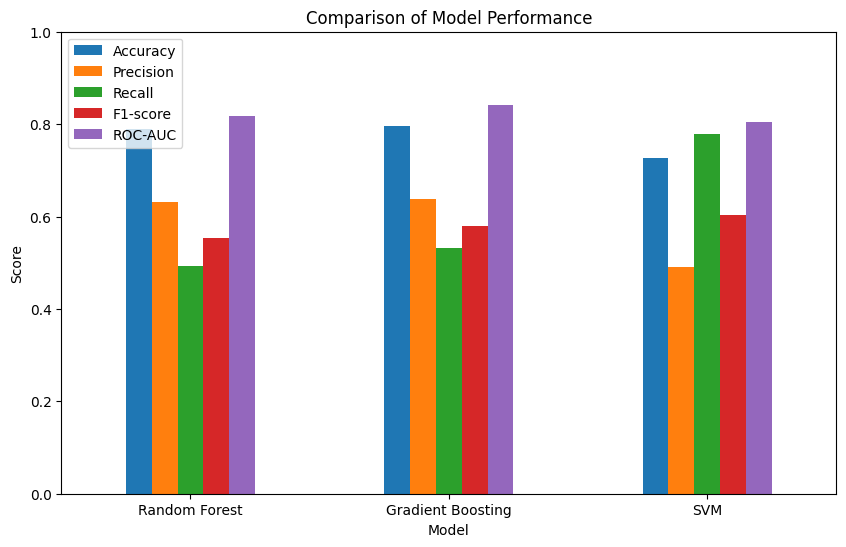

In [ ]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6))

plt.title("Comparison of Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## Interpretation of Results

Gradient Boosting obtained the highest accuracy and ROC-AUC score, which means it performed best overall. Random Forest had similar results but slightly lower performance.

SVM obtained the highest recall for churn customers. This means it was better at detecting customers who actually left the company, but it also produced more false positives. For a churn prediction problem, recall is important because companies usually want to identify as many potential churn customers as possible.

Overall, Gradient Boosting can be considered the best balanced model, while SVM is useful when the main goal is to detect as many churn customers as possible.

## Feature Importance

Feature importance helps us understand which variables had the strongest influence on the prediction. This is calculated using the Gradient Boosting model, because it had the best overall performance.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.317935
10,InternetService_Fiber optic,0.190840
28,PaymentMethod_Electronic check,0.104797
25,Contract_Two year,0.069253
3,TotalCharges,0.066989
2,MonthlyCharges,0.061475
24,Contract_One year,0.056428
13,OnlineSecurity_Yes,0.019964
26,PaperlessBilling_Yes,0.015879
14,OnlineBackup_No internet service,0.012426


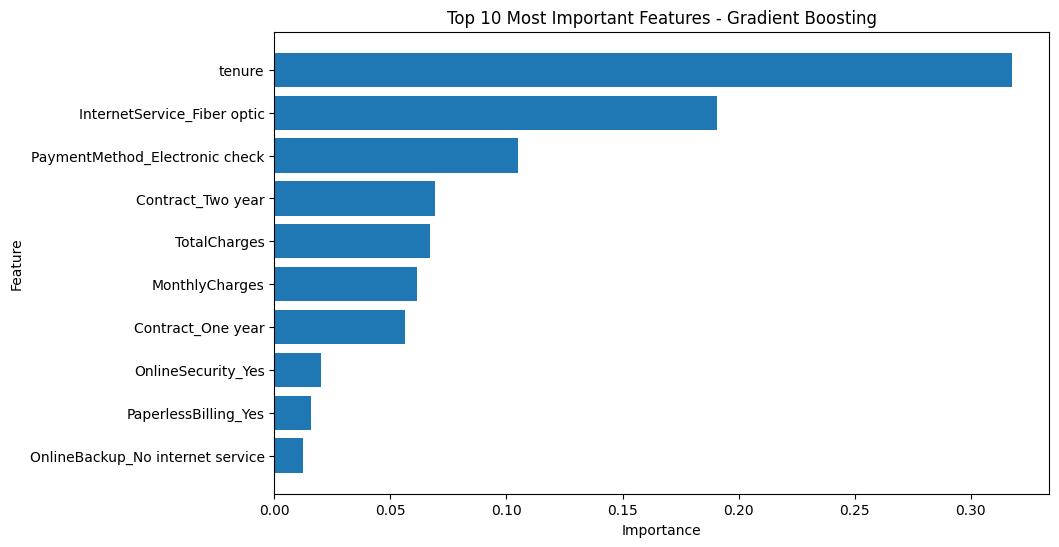

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Gradient Boosting")
plt.gca().invert_yaxis()
plt.show()

## Short Conclusion

The project used the Telco Customer Churn dataset for a classification task. The data was cleaned, encoded, split into training and test sets, and evaluated using three models: Random Forest, Gradient Boosting, and SVM.

Gradient Boosting had the best overall performance based on accuracy and ROC-AUC. SVM had the highest recall, meaning it detected more churn customers, but it also produced more false positives.

The most important factors for churn prediction were related to tenure, contract type, charges, and internet service.